<a href="https://colab.research.google.com/github/Thabhelo/traffic-density-classification/blob/main/Traffic_Density_Classification_with_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Overview
This dataset consists of images collected from the open-source API provided by Singapore's Land Transport Authority (LTA). The images are categorized into five traffic density levels: Empty, Low, Medium, High, and Traffic Jam. Out of 87 available traffic cameras, 20 were selected based on their ability to capture diverse and relevant images. Selection criteria included variability in traffic density, different lighting conditions, clear visibility (without obstructions), and suitable camera angles. A total of 4,054 images were manually labeled and then randomly divided into subsets: 80% for training, 10% for validation, and 10% for testing. To enhance robustness, the dataset includes images captured during both daytime and nighttime.

In [14]:
%pip install albumentations torch torchvision timm grad-cam seaborn numpy


Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
import copy
import warnings
import contextlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import timm
from timm.data import create_transform
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
from torch.amp import GradScaler

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("darkgrid")

# Device selection prioritizing Apple Silicon (MPS), then CUDA, then CPU
use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available()
if use_mps:
    device = torch.device("mps")
elif use_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


# Imports

In [16]:
np.random.seed(42)
torch.manual_seed(42)

# Configuration

In [17]:
# Paths
train_dir = "/content/traffic_density/Final Dataset/training"
val_dir = "/content/traffic_density/Final Dataset/validation"
test_dir = "/content/traffic_density/Final Dataset/testing"

# Classes and constants
classes = ['Empty', 'High', 'Low', 'Medium', 'Traffic Jam']
num_classes = len(classes)
batch_size = 16
image_size = 384

# Pin memory only for CUDA
pin_memory = (device.type == "cuda")

print(f"Using device: {device}")
print(f"Pin memory: {pin_memory}")

Using device: mps
Pin memory: False


# Exploratory data Analysis

In [18]:
!unzip traffic-density-singapore.zip -d /content/traffic_density

unzip:  cannot find or open traffic-density-singapore.zip, traffic-density-singapore.zip.zip or traffic-density-singapore.zip.ZIP.


In [19]:
directories=[train_dir,val_dir,test_dir]
img_shapes=[]

for i,directory in enumerate(directories):
    for density_dir_name in os.listdir(directory):
        density_dir_path=os.path.join(directory,density_dir_name)
        for img_file_name in os.listdir(density_dir_path):
            img_path=os.path.join(density_dir_path,img_file_name)
            img=cv2.imread(img_path)
            img_shapes.append([img.shape[0],img.shape[1],directory.split("/")[-1]])

img_shape_data=pd.DataFrame(data=img_shapes,columns=["height","width","split"])

FileNotFoundError: [Errno 2] No such file or directory: '/content/traffic_density/Final Dataset/training'

In [ ]:
img_shape_data.groupby("split")[["height","width"]].describe().T

split             testing     training   validation
height count   320.000000  3378.000000   340.000000
       mean    411.093750   402.775311   399.158824
       std     106.509852    99.681314    82.614208
       min     119.000000   130.000000   163.000000
       25%     360.000000   360.000000   360.000000
       50%     360.000000   360.000000   360.000000
       75%     480.000000   480.000000   480.000000
       max    1252.000000  2832.000000   800.000000
width  count   320.000000  3378.000000   340.000000
       mean    626.071875   609.701599   615.964706
       std     146.682642   134.039099    97.736651
       min     111.000000   250.000000   275.000000
       25%     640.000000   640.000000   640.000000
       50%     640.000000   640.000000   640.000000
       75%     640.000000   640.000000   640.000000
       max    1920.000000  4256.000000  1200.000000

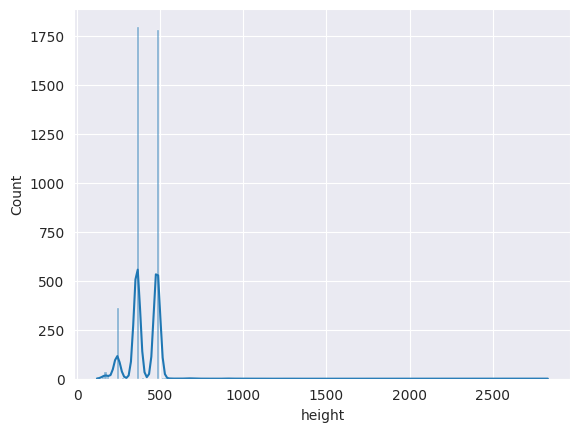

In [ ]:
sns.histplot(img_shape_data["height"],kde=True);

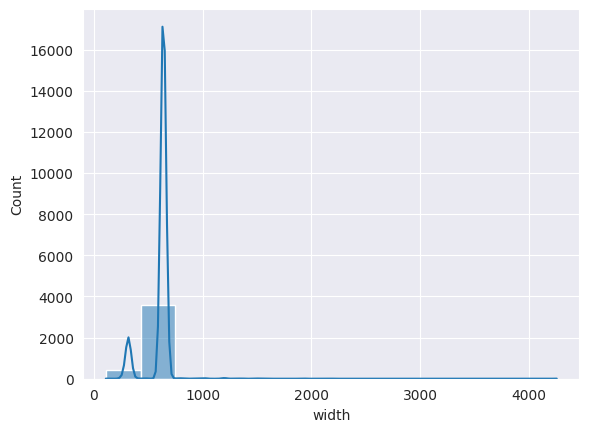

In [ ]:
sns.histplot(img_shape_data["width"],kde=True);

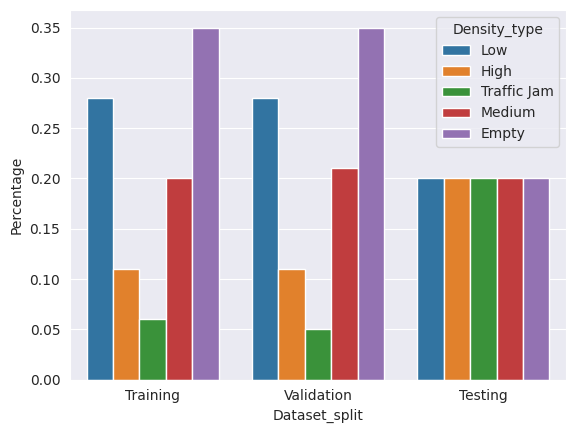

In [ ]:
directories=[train_dir,val_dir,test_dir]
total_instances=[3378,340,320]
instances_list=[]
for i,directory in enumerate(directories):
    for density_dir_name in os.listdir(directory):
        density_dir_path=os.path.join(directory,density_dir_name)
        instances=round(len(os.listdir(density_dir_path))/total_instances[i],2)
        instances_list.append([directory.split("/")[-1].capitalize(),density_dir_name,
                               instances])

inter=pd.DataFrame(data=instances_list,columns=["Dataset_split","Density_type","Percentage"])
sns.barplot(data=inter,x="Dataset_split",y="Percentage",hue="Density_type");

# Image Augmentation

In [ ]:
# Transforms (TIMM), 384x384, RandAugment + Random Erasing for train
train_transform = create_transform(
    input_size=(3, image_size, image_size),
    is_training=True,
    auto_augment='rand-m9-mstd0.5-inc1',
    interpolation='bicubic',
    re_prob=0.25,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

val_transform = create_transform(
    input_size=(3, image_size, image_size),
    is_training=False,
    interpolation='bicubic',
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

# Dataset

In [ ]:
# Datasets (PIL-based loader by default)
train_ds = ImageFolder(train_dir, transform=train_transform)
val_ds   = ImageFolder(val_dir,   transform=val_transform)
test_ds  = ImageFolder(test_dir,  transform=val_transform)

In [ ]:
# DataLoaders
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=os.cpu_count(), pin_memory=pin_memory)
val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=os.cpu_count(), pin_memory=pin_memory)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=os.cpu_count(), pin_memory=pin_memory)

# Data Visualization

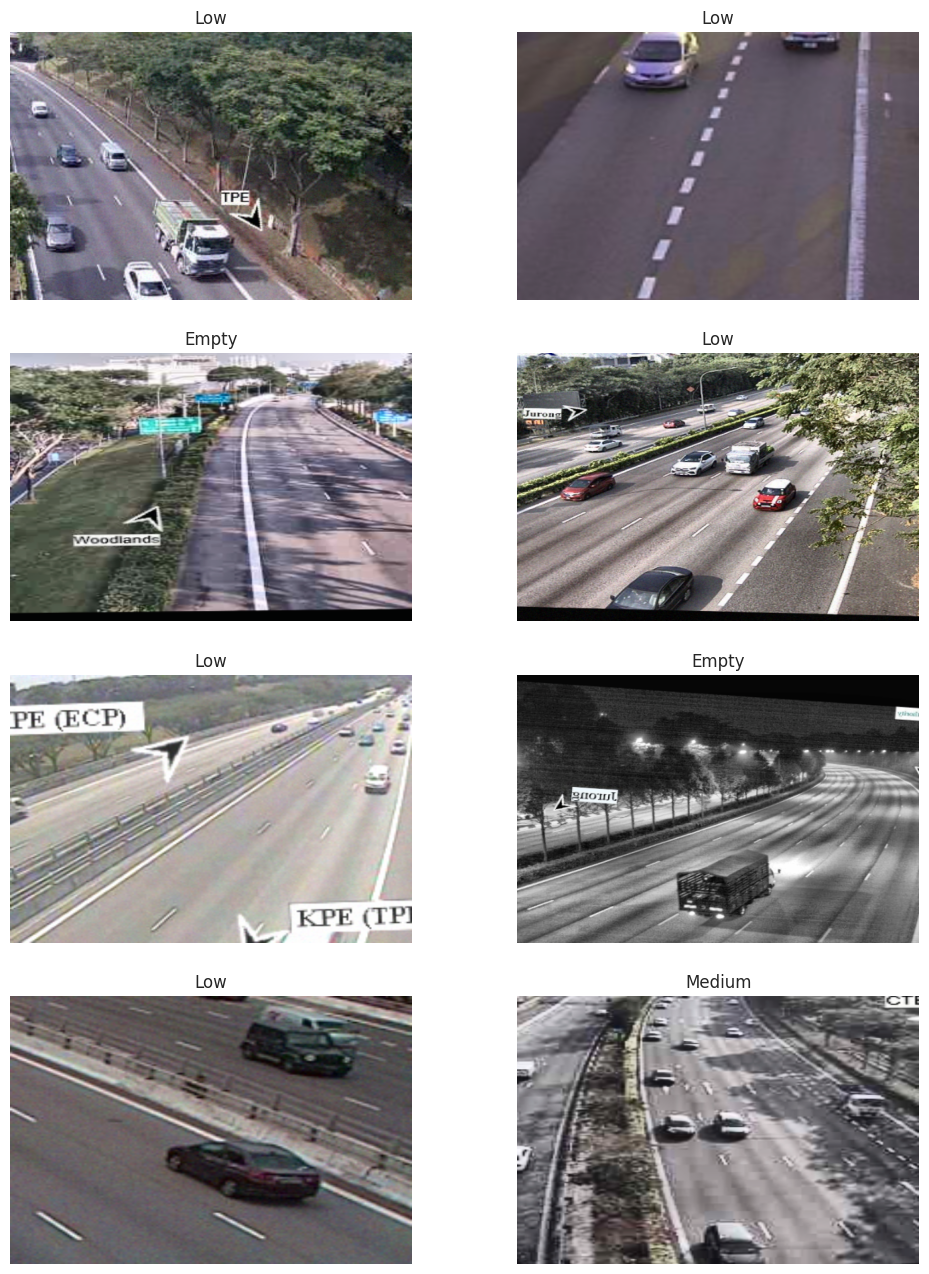

In [ ]:
# Show a batch of training images (unnormalized for display)
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

imgs, labels = next(iter(train_dl))
for i in range(min(8, imgs.size(0))):
    img = imgs[i].permute(1, 2, 0).cpu().numpy()
    img = (img * imagenet_std) + imagenet_mean
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i].item()])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# Training

In [ ]:
def train_epoch(model, dl, optimizer, scheduler, scaler, criterion, mixup_fn=None):
    model.train()
    running_loss = 0.0
    use_amp = (device.type in ("cuda", "mps"))
    for imgs, labels in dl:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if mixup_fn is not None:
            imgs, labels = mixup_fn(imgs, labels)

        optimizer.zero_grad(set_to_none=True)
        ctx = torch.autocast(device_type=device.type, dtype=torch.float16) if use_amp else contextlib.nullcontext()
        with ctx:
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        if scaler is not None and scaler.is_enabled():
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()
        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(dl.dataset)

@torch.no_grad()
def evaluate_epoch(model, dl, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in dl:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(dl.dataset), correct / total

In [ ]:
def build_model(num_classes: int) -> nn.Module:
    model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=True, num_classes=num_classes)
    model.to(device)

    return model

# Feature Extractor stage (ConvNeXt-Tiny)

In [ ]:
# Stage 1: Feature Extraction - freeze all except head
model = build_model(num_classes)

for name, param in model.named_parameters():
    if not name.startswith('head.'):  # ConvNeXt classifier head
        param.requires_grad = False

trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.AdamW(trainable_params, lr=1e-3, weight_decay=0.0)
scaler = GradScaler(enabled=(device.type == "cuda"))

# MixUp/CutMix + Soft Target loss for training; plain CE for validation
mixup_fn = Mixup(
    mixup_alpha=0.2, cutmix_alpha=1.0,
    prob=1.0, switch_prob=0.5,
    label_smoothing=0.1, num_classes=num_classes
)

criterion_train = SoftTargetCrossEntropy()
criterion_val = nn.CrossEntropyLoss()

epochs_stage1 = 10
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_dl),
    epochs=epochs_stage1,
    pct_start=0.1,
    anneal_strategy='cos'
)

best_w = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(epochs_stage1):
    train_loss = train_epoch(model, train_dl, optimizer, scheduler, scaler, criterion_train, mixup_fn)
    val_loss, val_acc = evaluate_epoch(model, val_dl, criterion_val)

    if val_acc > best_acc:
        best_acc = val_acc
        best_w = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{epochs_stage1} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

model.load_state_dict(best_w)
torch.save(model.state_dict(), "/content/convnext_feature_extractor.pth")

# Fine-tuning (ConvNeXt-Tiny)

In [ ]:
# Stage 2: Fine-tuning - unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
epochs_stage2 = 30
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_dl),
    epochs=epochs_stage2,
    pct_start=0.1,
    anneal_strategy='cos'
)

best_w = copy.deepcopy(model.state_dict())
best_acc = 0.0
for epoch in range(epochs_stage2):
    train_loss = train_epoch(model, train_dl, optimizer, scheduler, scaler, criterion_train, mixup_fn)
    val_loss, val_acc = evaluate_epoch(model, val_dl, criterion_val)

    if val_acc > best_acc:
        best_acc = val_acc
        best_w = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{epochs_stage2} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

model.load_state_dict(best_w)
torch.save(model.state_dict(), "/content/convnext_finetuned.pth")

<All keys matched successfully>

# Evaluation

In [ ]:
# Load best finetuned model
model = build_model(num_classes)
model.load_state_dict(torch.load("/content/convnext_finetuned.pth", map_location=device))
model.eval()

<All keys matched successfully>

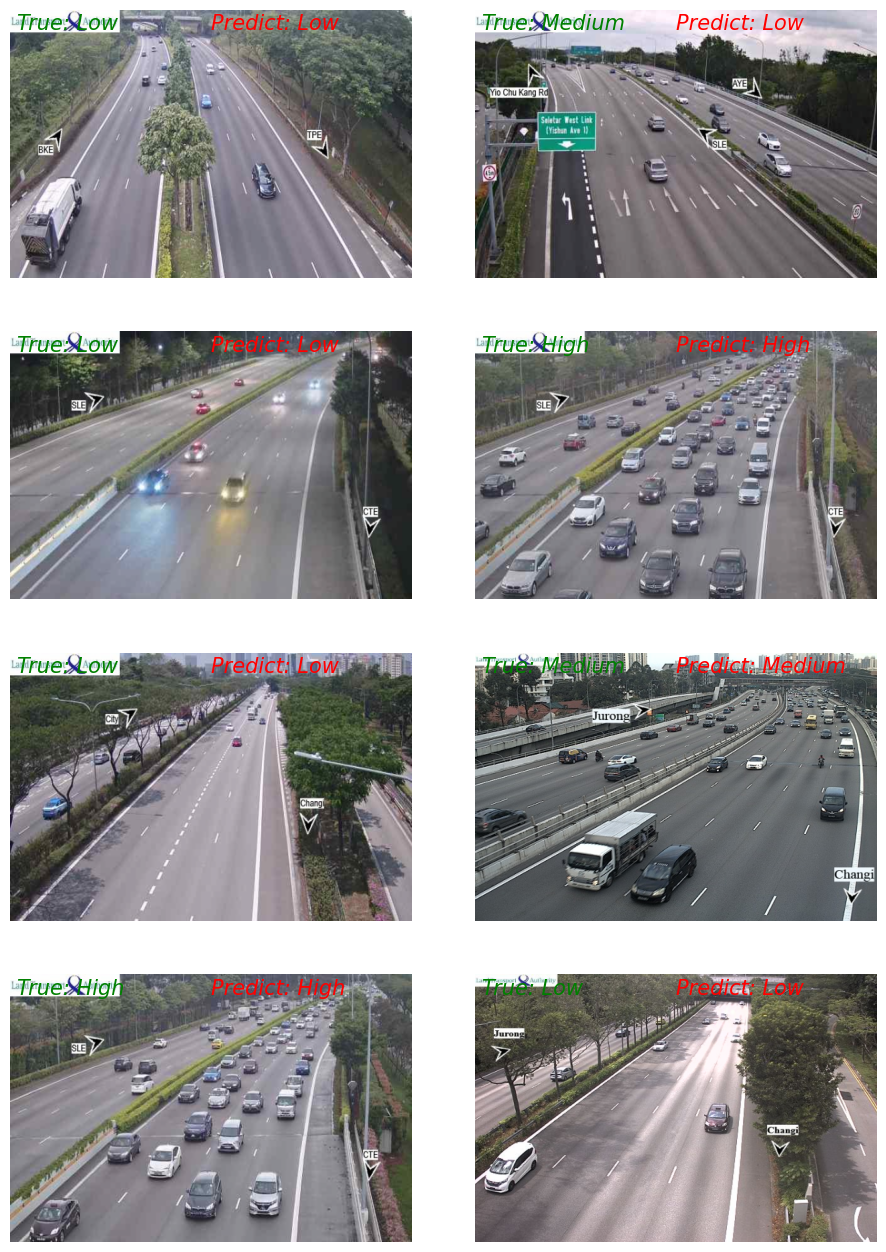

# Inference

In [ ]:
# Inference and classification report
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(labels.tolist())

print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=classes, columns=classes)
plt.figure(figsize=(6,6))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.show()

In [ ]:
# Optional (new capability) — Grad-CAM cell (add this after evaluation)
# Optional: Grad-CAM visualization for one image
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as T

# Pick one test image path and create a plain tensor pipeline for CAM
sample_path, sample_label = test_ds.samples[0]
rgb = Image.open(sample_path).convert("RGB")
to_tensor = T.Compose([
    T.Resize((image_size, image_size), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])
input_tensor = to_tensor(rgb).unsqueeze(0).to(device)

# For ConvNeXt-Tiny, last stage block works well
target_layers = [model.stages[-1].blocks[-1].dwconv] if hasattr(model.stages[-1].blocks[-1], "dwconv") else [model.stages[-1].blocks[-1]]
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=use_cuda)
pred = model(input_tensor).argmax(1).item()

grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred)])[0]
rgb_float = np.array(rgb).astype(np.float32) / 255.0
cam_image = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(rgb); plt.title(f"True: {classes[sample_label]}"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cam_image); plt.title(f"Grad-CAM: {classes[pred]}"); plt.axis('off')
plt.show()

              precision    recall  f1-score   support

           0       0.98      0.95      0.97        64
           1       0.89      0.91      0.90        64
           2       0.86      0.89      0.88        64
           3       0.82      0.84      0.83        64
           4       1.00      0.95      0.98        64

    accuracy                           0.91       320
   macro avg       0.91      0.91      0.91       320
weighted avg       0.91      0.91      0.91       320

